# Strategy & Risk: Full Position Lifecycle Demo

This notebook demonstrates the complete trading lifecycle from signal generation through position exit.

**Components Demonstrated:**
- **Signal Generation**: Model predictions to trading signals
- **Structure Selection**: Signals to Calendar/Vertical spreads
- **Risk Management**: Pre-trade checks, stress testing, kill switch
- **Position Tracking**: Entry to mark-to-market to exit
- **Exit Management**: Stop-loss, take-profit, time decay, edge decay

**Key Insight**: Positions both ENTER and EXIT based on market conditions, showing realistic P&L and Greek evolution.

---

> **Note: Synthetic Data**
> 
> This notebook uses **randomly generated** surfaces and signals for demonstration purposes.
> The trading signals have no real predictive power, so expect flat or negative performance.
> This is expected behavior—the goal is to validate the strategy mechanics (structure creation,
> risk checks, position tracking, exit signals), not to demonstrate a profitable strategy.
> With real market data and trained models, performance would reflect actual strategy edge.

## Part 1: Setup

Import all components and configure the trading system.

In [25]:
import sys
sys.path.insert(0, '..')

from datetime import date, datetime, timezone, timedelta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# Strategy imports
from src.strategy import (
    Greeks, OptionLeg, OptionRight, Signal, SignalType, ExitSignal, ExitSignalType,
    CONTRACT_MULTIPLIER, TradeStructure, CalendarSpread, VerticalSpread,
    StructureSelector, PositionSizer, SizingResult,
    Order, OrderGenerator, OrderGenerationResult,
)
from src.strategy.structures import SkewTrade, IronCondor

# Position Management imports
from src.strategy.positions import (
    ManagedPosition, ExitSignalGenerator, ExitOrder, ExitOrderGenerator,
    RebalanceEngine, DriftResult, DriftStatus, PositionManager, Fill,
)

# Risk imports
from src.risk import (
    Portfolio, Position, PositionState,
    StressEngine, StressResult,
    RiskChecker, RiskCheckResult, RiskCheckStatus,
    KillSwitch, KillSwitchTrigger,
)

# Config imports
from src.config.schema import (
    ExecutionConfig, RiskConfig, SignalThresholdConfig, SizingConfig, PricingConfig,
    PerTradeRiskConfig, RiskCapsConfig, StressConfig, KillSwitchConfig,
    PositionManagementConfig, ExitSignalsConfig, RebalancingConfig, DriftBandsConfig,
)

print(f"CONTRACT_MULTIPLIER: {CONTRACT_MULTIPLIER}")
print(f"Signal types: {[s.value for s in SignalType]}")
print(f"Exit types: {[s.value for s in ExitSignalType]}")
print(f"Structures: CalendarSpread, VerticalSpread, SkewTrade, IronCondor")

CONTRACT_MULTIPLIER: 100
Signal types: ['term_anomaly', 'directional_vol', 'skew_anomaly', 'elevated_iv']
Exit types: ['model_reversal', 'edge_decay', 'stop_loss', 'take_profit', 'time_decay', 'rebalance', 'manual']
Structures: CalendarSpread, VerticalSpread, SkewTrade, IronCondor


In [26]:
# System Configuration
execution_config = ExecutionConfig(
    pricing=PricingConfig(use_mid_price=True, spread_buffer_pct=0.02),
    signal_threshold=SignalThresholdConfig(min_edge=0.02, min_confidence=0.6),
    sizing=SizingConfig(base_contracts=1, max_contracts_per_trade=5, kelly_fraction=0.25),
)

risk_config = RiskConfig(
    per_trade=PerTradeRiskConfig(max_loss=500.0, max_contracts=10),
    caps=RiskCapsConfig(max_abs_delta=500.0, max_abs_vega=2000.0, max_daily_loss=10000.0),
    stress=StressConfig(spot_shocks=[-0.10, -0.05, 0.05, 0.10], vol_shocks=[-0.20, 0.20, 0.50]),
    kill_switch=KillSwitchConfig(max_daily_loss=2000.0),
)

position_management_config = PositionManagementConfig(
    exit_signals=ExitSignalsConfig(
        min_edge_retention=0.3,
        stop_loss_pct=0.7,      # Exit at 70% of max loss
        take_profit_pct=0.5,   # Exit at 50% profit (of max loss)
        min_dte_exit=3,        # Exit when DTE <= 3
    ),
    rebalancing=RebalancingConfig(enabled=True, strategy="close_first", max_trades_per_rebalance=3),
    drift_bands=DriftBandsConfig(delta_target=0.0, delta_max_drift=100.0, vega_target=0.0, vega_max_drift=500.0),
)

# Constants for simulation
MAX_OPEN_POSITIONS = 10

print("Configuration loaded:")
print(f"  Min edge: {execution_config.signal_threshold.min_edge:.0%}")
print(f"  Min confidence: {execution_config.signal_threshold.min_confidence:.0%}")
print(f"  Stop-loss: {position_management_config.exit_signals.stop_loss_pct:.0%} of max loss")
print(f"  Take-profit: {position_management_config.exit_signals.take_profit_pct:.0%} of max loss")
print(f"  Min DTE: {position_management_config.exit_signals.min_dte_exit} days")

Configuration loaded:
  Min edge: 2%
  Min confidence: 60%
  Stop-loss: 70% of max loss
  Take-profit: 50% of max loss
  Min DTE: 3 days


## Part 2: Build Simulated Market Surface

Create a realistic options surface with multiple tenors and strikes.

In [27]:
def build_surface(base_date: date, underlying_price: float = 450.0, base_iv: float = 0.20) -> pd.DataFrame:
    """Build a simulated options surface with calls and puts at each strike.
    
    Uses FIXED monthly expiries AND fixed strikes to ensure option symbols
    persist across trading days. This allows proper position tracking and exit pricing.
    
    Includes wing options (10P, 10C) for SkewTrade and IronCondor structures.
    
    Note: Greeks vary by moneyness (ATM options have higher vega/gamma/theta)
    to ensure spread structures have non-zero net Greeks.
    """
    # Use fixed monthly expiry dates (3rd Friday convention simplified)
    fixed_expiries = [
        date(2024, 2, 16),   # Feb expiry
        date(2024, 3, 15),   # Mar expiry
        date(2024, 4, 19),   # Apr expiry
        date(2024, 5, 17),   # May expiry
        date(2024, 6, 21),   # Jun expiry
    ]
    
    # Filter to expiries that haven't passed yet
    valid_expiries = [exp for exp in fixed_expiries if exp > base_date]
    
    # Use FIXED strikes (standard $5 increments) - extended range for wing options
    # Range 360-540 (~20% from ATM) ensures we can always find wing strikes
    fixed_strikes = list(range(360, 545, 5))  # 360, 365, 370, ... 540
    
    rows = []
    for expiry in valid_expiries:
        tenor = (expiry - base_date).days
        if tenor < 1:
            continue
            
        t = tenor / 365.0
        
        for strike in fixed_strikes:
            # Map strikes to delta buckets based on moneyness
            moneyness_pct = strike / underlying_price
            if moneyness_pct <= 0.88:
                bucket = "10P"      # Wing put (deep OTM)
            elif moneyness_pct <= 0.95:
                bucket = "25P"
            elif moneyness_pct <= 0.97:
                bucket = "15P"
            elif moneyness_pct <= 1.03:
                bucket = "ATM"
            elif moneyness_pct <= 1.05:
                bucket = "15C"
            elif moneyness_pct <= 1.12:
                bucket = "25C"
            else:
                bucket = "10C"      # Wing call (deep OTM)
            
            # IV with term structure and skew
            term_adj = 0.02 * (30 - tenor) / 30
            skew_adj = 0.03 * (1.0 - moneyness_pct)  # Higher IV for lower strikes
            iv = max(0.10, base_iv + term_adj + skew_adj + np.random.normal(0, 0.005))
            
            # Greeks with moneyness factor
            # ATM options have highest gamma/vega, decreasing for OTM
            moneyness = moneyness_pct - 1.0
            atm_factor = max(0.2, 1.0 - abs(moneyness) * 3)  # 1.0 at ATM, ~0.4 at 20% OTM
            
            for right in ["C", "P"]:
                # Delta based on moneyness and right
                if right == "C":
                    delta = max(0.05, min(0.95, 0.5 - moneyness * 2 + np.random.normal(0, 0.02)))
                else:
                    delta = -max(0.05, min(0.95, 0.5 + moneyness * 2 + np.random.normal(0, 0.02)))
                
                # Apply moneyness factor so spreads have non-zero net Greeks
                gamma = 0.03 / (iv * np.sqrt(t) + 0.01) * atm_factor
                vega = underlying_price * np.sqrt(t) * 0.004 * atm_factor
                theta = -underlying_price * iv / (2 * np.sqrt(t) * 365) * 0.01 * atm_factor
                
                # Price
                intrinsic = max(0, underlying_price - strike) if right == "C" else max(0, strike - underlying_price)
                time_value = underlying_price * iv * np.sqrt(t) * 0.4
                mid_price = max(0.20, intrinsic + time_value * (1 - abs(moneyness)))
                spread = mid_price * 0.03
                
                # FIXED symbol format - uses fixed expiry and fixed strike
                symbol = f"SPY{expiry.strftime('%y%m%d')}{right}{int(strike*1000):08d}"
                
                rows.append({
                    "option_symbol": symbol,
                    "underlying_price": underlying_price,
                    "tenor_days": tenor,
                    "delta_bucket": bucket,
                    "strike": float(strike),
                    "expiry": expiry,
                    "right": right,
                    "iv": iv,
                    "bid": round(mid_price - spread/2, 2),
                    "ask": round(mid_price + spread/2, 2),
                    "delta": round(delta, 3),
                    "gamma": round(gamma, 4),
                    "vega": round(vega, 3),
                    "theta": round(theta, 4),
                })
    
    return pd.DataFrame(rows)

# Build initial surface
base_date = date(2024, 2, 1)
surface = build_surface(base_date)
print(f"Surface shape: {surface.shape}")
print(f"Fixed expiries: {sorted(surface['expiry'].unique())}")
print(f"Fixed strikes: {sorted(surface['strike'].unique())[:3]}...{sorted(surface['strike'].unique())[-3:]}")
print(f"Delta buckets: {sorted(surface['delta_bucket'].unique())}")
surface[["tenor_days", "delta_bucket", "strike", "right", "bid", "ask", "delta", "vega"]].head(10)

Surface shape: (370, 14)
Fixed expiries: [datetime.date(2024, 2, 16), datetime.date(2024, 3, 15), datetime.date(2024, 4, 19), datetime.date(2024, 5, 17), datetime.date(2024, 6, 21)]
Fixed strikes: [np.float64(360.0), np.float64(365.0), np.float64(370.0)]...[np.float64(530.0), np.float64(535.0), np.float64(540.0)]
Delta buckets: ['10C', '10P', '15C', '15P', '25C', '25P', 'ATM']


,tenor_days,delta_bucket,strike,right,bid,ask,delta,vega
0,15,10P,360.0,C,94.93,97.82,0.897,0.146
1,15,10P,360.0,P,6.28,6.47,-0.113,0.146
2,15,10P,365.0,C,90.23,92.98,0.873,0.158
3,15,10P,365.0,P,6.51,6.71,-0.118,0.158
4,15,10P,370.0,C,85.40,88.00,0.871,0.170
5,15,10P,370.0,P,6.60,6.80,-0.135,0.170
6,15,10P,375.0,C,80.40,82.84,0.824,0.182
7,15,10P,375.0,P,6.52,6.72,-0.157,0.182
8,15,10P,380.0,C,75.50,77.80,0.773,0.195
9,15,10P,380.0,P,6.55,6.75,-0.154,0.195


## Part 3: Initialize Trading Components

Set up the order generator, risk checker, and position manager.

In [28]:
# Initialize components
structure_selector = StructureSelector(config=execution_config)
position_sizer = PositionSizer(config=execution_config.sizing)

risk_checker = RiskChecker(config=risk_config)
stress_engine = StressEngine(config=risk_config.stress)
kill_switch = KillSwitch(config=risk_config.kill_switch)

order_generator = OrderGenerator(
    config=execution_config,
    risk_checker=risk_checker,
    structure_selector=structure_selector,
    position_sizer=position_sizer,
)

exit_signal_gen = ExitSignalGenerator(config=position_management_config.exit_signals)
exit_order_gen = ExitOrderGenerator(config=execution_config)
rebalance_engine = RebalanceEngine(
    rebalancing_config=position_management_config.rebalancing,
    drift_bands_config=position_management_config.drift_bands,
)

position_manager = PositionManager(
    config=position_management_config,
    exit_signal_generator=exit_signal_gen,
    exit_order_generator=exit_order_gen,
    rebalance_engine=rebalance_engine,
)

portfolio = Portfolio()

print("Components initialized:")
print(f"  OrderGenerator: ready")
print(f"  RiskChecker: max_loss=${risk_config.per_trade.max_loss}")
print(f"  PositionManager: ready")

Components initialized:
  OrderGenerator: ready
  RiskChecker: max_loss=$500.0
  PositionManager: ready


## Part 4: Multi-Period Lifecycle Simulation

Run a 30-day simulation where:
1. New signals arrive each period
2. Positions are opened (subject to risk checks)
3. Existing positions are marked-to-market
4. Exit signals trigger position closes (stop-loss, take-profit, DTE)
5. Track P&L and Greek exposure over time

In [29]:
def generate_random_signal(surface: pd.DataFrame, period: int) -> Signal:
    """Generate a random trading signal from surface nodes.
    
    Now includes all 4 signal types:
    - TERM_ANOMALY -> CalendarSpread
    - DIRECTIONAL_VOL -> VerticalSpread  
    - SKEW_ANOMALY -> SkewTrade
    - ELEVATED_IV -> IronCondor
    
    Note: Signal generation is tenor and delta-bucket aware:
    - Excludes near-term expiries (< 20 days) to ensure options stay in surface
    - Calendar spreads exclude longest 2 tenors to ensure far leg exists
    - Vertical spreads exclude extreme delta buckets (10P, 10C) since they need
      strikes on both sides of the anchor
    """
    # All 4 signal types with realistic probabilities
    signal_types = [
        SignalType.TERM_ANOMALY,
        SignalType.DIRECTIONAL_VOL,
        SignalType.SKEW_ANOMALY,
        SignalType.ELEVATED_IV,
    ]
    # Weights: term 25%, directional 35%, skew 20%, elevated_iv 20%
    signal_type = signal_types[np.random.choice([0, 1, 2, 3], p=[0.25, 0.35, 0.20, 0.20])]
    
    # Get available tenors, excluding near-term (< 20 days) to avoid expiry issues
    # Options with < 20 days may expire during the 30-day simulation
    available_tenors = sorted(surface["tenor_days"].unique())
    valid_tenors = [t for t in available_tenors if t >= 20]
    
    # If no valid tenors after filtering, use all (shouldn't happen with our dates)
    if not valid_tenors:
        valid_tenors = available_tenors
    
    # For calendar spreads, also exclude longest 2 tenors to ensure far leg exists
    if signal_type == SignalType.TERM_ANOMALY and len(valid_tenors) > 2:
        valid_tenors = valid_tenors[:-2]
    
    # Filter surface to valid tenors
    eligible_surface = surface[surface["tenor_days"].isin(valid_tenors)]
    
    # For DIRECTIONAL_VOL (vertical spreads), exclude extreme delta buckets
    # Vertical spreads need strikes on BOTH sides of the anchor, so 10P/10C 
    # at the edges of our strike range will fail for negative/positive edge
    if signal_type == SignalType.DIRECTIONAL_VOL:
        eligible_surface = eligible_surface[
            ~eligible_surface["delta_bucket"].isin(["10P", "10C"])
        ]
    
    if eligible_surface.empty:
        # Fallback to full surface if filtering is too aggressive
        eligible_surface = surface
    
    node = eligible_surface.sample(1).iloc[0]
    
    # Random edge between 2% and 8%
    edge = np.random.uniform(0.02, 0.08) * np.random.choice([1, -1])
    
    # Confidence above min_confidence threshold (0.6) for all signal types
    # Note: ELEVATED_IV conceptually works with "neutral view" but we still need
    # confidence >= 0.6 to pass the threshold check. The iron condor structure
    # is appropriate regardless of confidence level.
    confidence = np.random.uniform(0.6, 0.9)
    
    return Signal(
        signal_type=signal_type,
        edge=edge,
        confidence=confidence,
        tenor_days=int(node["tenor_days"]),  # Convert from numpy
        delta_bucket=str(node["delta_bucket"]),  # Convert from numpy
    )


def simulate_fill(order: Order, surface: pd.DataFrame) -> Fill:
    """Simulate order fill with slight slippage."""
    slippage = np.random.uniform(0.98, 1.02)
    fill_price = sum(
        leg.qty * leg.entry_price * CONTRACT_MULTIPLIER 
        for leg in order.legs
    ) * slippage
    
    return Fill(
        legs=order.legs,
        fill_price=fill_price,
        timestamp=datetime.now(timezone.utc),
    )


def update_position_mtm(position: ManagedPosition, surface: pd.DataFrame, days_passed: int):
    """Update position mark-to-market and days to expiry."""
    pnl_change = np.random.normal(0, position.max_loss * 0.15)
    position.unrealized_pnl = position.unrealized_pnl + pnl_change
    
    if position.days_to_expiry > 0:
        position.days_to_expiry = max(0, position.days_to_expiry - 1)

print("Simulation functions defined.")
print("Signal type distribution: TERM_ANOMALY 25%, DIRECTIONAL_VOL 35%, SKEW_ANOMALY 20%, ELEVATED_IV 20%")
print("Note: Signals exclude near-term expiries (< 20 days) and extreme delta buckets for vertical spreads")

Simulation functions defined.
Signal type distribution: TERM_ANOMALY 25%, DIRECTIONAL_VOL 35%, SKEW_ANOMALY 20%, ELEVATED_IV 20%
Note: Signals exclude near-term expiries (< 20 days) and extreme delta buckets for vertical spreads


In [30]:
# Run simulation
n_periods = 30
history = {
    "period": [],
    "open_positions": [],
    "entries": [],
    "exits": [],
    "portfolio_delta": [],
    "portfolio_vega": [],
    "unrealized_pnl": [],
    "realized_pnl": [],
    "total_pnl": [],
}

exit_reasons = []  # Track why positions exited
cumulative_realized = 0.0

print("=" * 70)
print("SIMULATION START")
print("=" * 70)

for period in range(n_periods):
    current_date = base_date + timedelta(days=period)
    surface = build_surface(current_date)
    
    entries_this_period = 0
    exits_this_period = 0
    
    # === PHASE 1: Update existing positions ===
    for pos in position_manager.get_open_positions():
        update_position_mtm(pos, surface, period)
    
    # === PHASE 2: Check for exits ===
    exit_orders = position_manager.evaluate_exits(
        surface=surface,
        model_predictions=None,  # No model predictions in this sim
        portfolio=portfolio,
    )
    
    for exit_order in exit_orders:
        # Get the position being closed
        pos = position_manager.get_position(exit_order.position_id)
        if pos is None:
            continue
        
        # Simulate exit fill with slippage
        # exit_price = entry_price + unrealized_pnl (with small slippage)
        # This ensures realized_pnl = exit_price - entry_price ≈ unrealized_pnl
        slippage = np.random.uniform(0.9, 1.1)
        exit_fill_price = pos.entry_price + pos.unrealized_pnl * slippage
        position_manager.record_exit(exit_order, fill_price=exit_fill_price)
        
        # Track exit reason
        exit_reasons.append(exit_order.exit_signal.exit_type.value)
        cumulative_realized += pos.realized_pnl or 0
        exits_this_period += 1
        
        # Log all exits
        print(f"[Period {period:2d}] EXIT: {exit_order.exit_signal.exit_type.value:12s} | "
              f"P&L: ${pos.realized_pnl or 0:+.0f} | "
              f"Reason: {exit_order.exit_signal.reason[:40]}")
    
    # === PHASE 3: Generate new signals and enter positions ===
    # Generate 0-2 signals per period
    n_signals = np.random.choice([0, 1, 1, 2], p=[0.3, 0.4, 0.2, 0.1])
    
    for _ in range(n_signals):
        if len(position_manager.get_open_positions()) >= MAX_OPEN_POSITIONS:
            break  # Hit position limit
            
        signal = generate_random_signal(surface, period)
        
        # Generate order
        result = order_generator.generate_orders(
            signals=[signal],
            surface=surface,
            portfolio=portfolio,
            underlying_price=450.0,
        )
        
        if not result.orders:
            continue
            
        order = result.orders[0]
        
        # Risk check
        risk_result = risk_checker.check_trade(
            legs=order.legs,
            portfolio=portfolio,
            underlying_price=450.0,
        )
        if risk_result.status != RiskCheckStatus.APPROVED:
            continue
        
        # Simulate fill and add position
        fill = simulate_fill(order, surface)
        position = position_manager.add_position(order, fill)
        
        # Set initial DTE
        min_expiry = min(leg.expiry for leg in position.legs)
        position.days_to_expiry = (min_expiry - current_date).days
        
        entries_this_period += 1
        
        # Log all entries
        print(f"[Period {period:2d}] ENTRY: {position.structure_type:15s} | "
              f"Max Loss: ${position.max_loss:.0f} | DTE: {position.days_to_expiry}")
    
    # === Record metrics ===
    open_positions = position_manager.get_open_positions()
    total_delta = sum(p.entry_greeks.delta * CONTRACT_MULTIPLIER for p in open_positions)
    total_vega = sum(p.entry_greeks.vega * CONTRACT_MULTIPLIER for p in open_positions)
    unrealized = sum(p.unrealized_pnl for p in open_positions)
    
    history["period"].append(period)
    history["open_positions"].append(len(open_positions))
    history["entries"].append(entries_this_period)
    history["exits"].append(exits_this_period)
    history["portfolio_delta"].append(total_delta)
    history["portfolio_vega"].append(total_vega)
    history["unrealized_pnl"].append(unrealized)
    history["realized_pnl"].append(cumulative_realized)
    history["total_pnl"].append(unrealized + cumulative_realized)

print("\n" + "=" * 70)
print("SIMULATION COMPLETE")
print("=" * 70)

# Summary
summary = position_manager.get_portfolio_summary()
print(f"\nFinal Summary:")
print(f"  Open positions: {summary['open_count']}")
print(f"  Closed positions: {summary['closed_count']}")
print(f"  Total entries: {sum(history['entries'])}")
print(f"  Total exits: {sum(history['exits'])}")
print(f"  Realized P&L: ${summary['total_realized_pnl']:+,.0f}")
print(f"  Unrealized P&L: ${summary['total_unrealized_pnl']:+,.0f}")
print(f"  Total P&L: ${summary['total_pnl']:+,.0f}")

SIMULATION START
[Period  8] ENTRY: IronCondor      | Max Loss: $1116 | DTE: 35
[Period  8] ENTRY: VerticalSpread  | Max Loss: $31 | DTE: 70
[Period 11] ENTRY: IronCondor      | Max Loss: $1030 | DTE: 130
[Period 13] ENTRY: IronCondor      | Max Loss: $1080 | DTE: 30
[Period 13] ENTRY: VerticalSpread  | Max Loss: $4 | DTE: 65
[Period 15] ENTRY: SkewTrade       | Max Loss: $1503 | DTE: 63
[Period 17] ENTRY: IronCondor      | Max Loss: $1061 | DTE: 61
[Period 18] ENTRY: CalendarSpread  | Max Loss: $331 | DTE: 25
[Period 20] ENTRY: IronCondor      | Max Loss: $1011 | DTE: 121
[Period 21] EXIT: stop_loss    | P&L: $-737 | Reason: Stop-loss triggered: 75.5% of max loss r
[Period 22] EXIT: take_profit  | P&L: $+671 | Reason: Take-profit triggered: 57.6% profit of m
[Period 22] ENTRY: IronCondor      | Max Loss: $1020 | DTE: 21
[Period 22] ENTRY: VerticalSpread  | Max Loss: $23 | DTE: 119
[Period 23] ENTRY: SkewTrade       | Max Loss: $1577 | DTE: 83
[Period 26] EXIT: take_profit  | P&L: $+86

## Part 5: Visualization

Visualize the full position lifecycle including entries, exits, P&L, and Greek exposure.

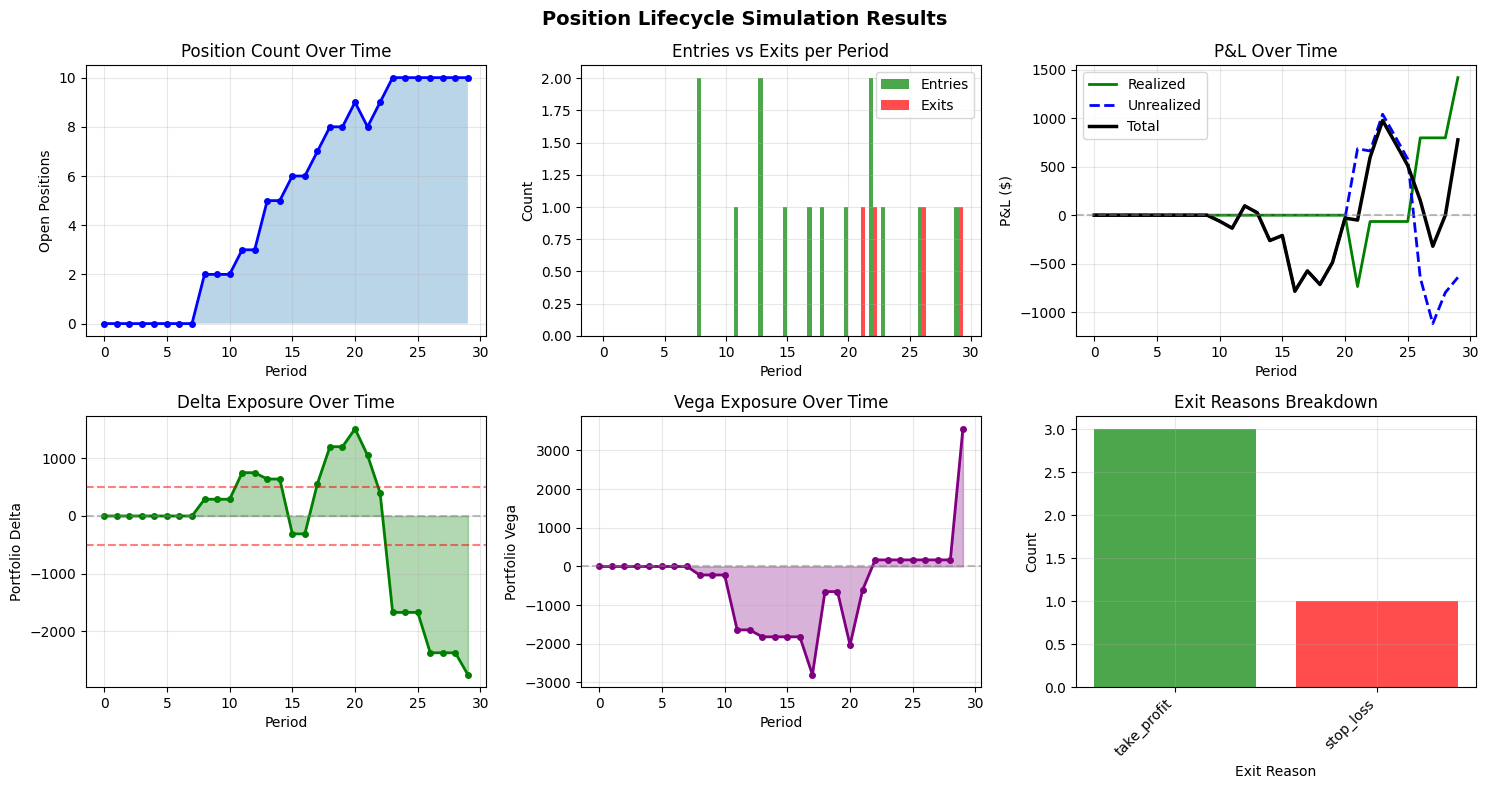

In [31]:
df = pd.DataFrame(history)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Position Lifecycle Simulation Results", fontsize=14, fontweight="bold")

# 1. Position count over time
ax = axes[0, 0]
ax.plot(df["period"], df["open_positions"], "b-", linewidth=2, marker="o", markersize=4)
ax.fill_between(df["period"], 0, df["open_positions"], alpha=0.3)
ax.set_xlabel("Period")
ax.set_ylabel("Open Positions")
ax.set_title("Position Count Over Time")
ax.grid(True, alpha=0.3)

# 2. Entries vs Exits per period
ax = axes[0, 1]
width = 0.35
x = df["period"]
ax.bar(x - width/2, df["entries"], width, label="Entries", color="green", alpha=0.7)
ax.bar(x + width/2, df["exits"], width, label="Exits", color="red", alpha=0.7)
ax.set_xlabel("Period")
ax.set_ylabel("Count")
ax.set_title("Entries vs Exits per Period")
ax.legend()
ax.grid(True, alpha=0.3)

# 3. P&L over time
ax = axes[0, 2]
ax.plot(df["period"], df["realized_pnl"], "g-", linewidth=2, label="Realized")
ax.plot(df["period"], df["unrealized_pnl"], "b--", linewidth=2, label="Unrealized")
ax.plot(df["period"], df["total_pnl"], "k-", linewidth=2.5, label="Total")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Period")
ax.set_ylabel("P&L ($)")
ax.set_title("P&L Over Time")
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Portfolio Delta
ax = axes[1, 0]
ax.plot(df["period"], df["portfolio_delta"], "g-", linewidth=2, marker="o", markersize=4)
ax.fill_between(df["period"], 0, df["portfolio_delta"], alpha=0.3, color="green")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.axhline(y=risk_config.caps.max_abs_delta, color="red", linestyle="--", alpha=0.5, label="Limit")
ax.axhline(y=-risk_config.caps.max_abs_delta, color="red", linestyle="--", alpha=0.5)
ax.set_xlabel("Period")
ax.set_ylabel("Portfolio Delta")
ax.set_title("Delta Exposure Over Time")
ax.grid(True, alpha=0.3)

# 5. Portfolio Vega
ax = axes[1, 1]
ax.plot(df["period"], df["portfolio_vega"], "purple", linewidth=2, marker="o", markersize=4)
ax.fill_between(df["period"], 0, df["portfolio_vega"], alpha=0.3, color="purple")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Period")
ax.set_ylabel("Portfolio Vega")
ax.set_title("Vega Exposure Over Time")
ax.grid(True, alpha=0.3)

# 6. Exit reasons breakdown
ax = axes[1, 2]
if exit_reasons:
    reason_counts = pd.Series(exit_reasons).value_counts()
    colors = {"stop_loss": "red", "take_profit": "green", "time_decay": "orange", "edge_decay": "blue", "manual": "gray"}
    bar_colors = [colors.get(r, "gray") for r in reason_counts.index]
    ax.bar(reason_counts.index, reason_counts.values, color=bar_colors, alpha=0.7)
    ax.set_xlabel("Exit Reason")
    ax.set_ylabel("Count")
    ax.set_title("Exit Reasons Breakdown")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
else:
    ax.text(0.5, 0.5, "No exits occurred", ha="center", va="center", transform=ax.transAxes)
    ax.set_title("Exit Reasons Breakdown")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Part 6: Individual Component Demos

Demonstrate key components in isolation.

### 6.1 Greeks Arithmetic

In [32]:
# Greeks support scaling and addition
call_greeks = Greeks(delta=0.50, gamma=0.025, vega=0.20, theta=-0.05)
put_greeks = Greeks(delta=-0.30, gamma=0.020, vega=0.15, theta=-0.04)

# Scale by 2 contracts
scaled = call_greeks.scale(2 * CONTRACT_MULTIPLIER)
print(f"2 ATM calls: delta={scaled.delta:.0f}, vega={scaled.vega:.0f}")

# Combine positions
combined = call_greeks + put_greeks
print(f"Combined: {combined}")

2 ATM calls: delta=100, vega=40
Combined: Greeks(delta=0.2, gamma=0.045, vega=0.35, theta=-0.09)


### 6.2 Trade Structure Creation

In [33]:
# Create structures from signals - demonstrating all 4 structure types
surface = build_surface(date(2024, 2, 1))

# Query surface for available tenors and delta buckets
available_tenors = sorted(surface["tenor_days"].unique())
available_buckets = surface["delta_bucket"].unique()
print(f"Available tenors: {available_tenors}")
print(f"Available buckets: {list(available_buckets)}")

# Use the nearest tenor for single-expiry structures (vertical, skew, iron condor)
# Use two tenors for calendar spread
near_tenor = available_tenors[0]  # e.g., 15 days
far_tenor = available_tenors[1] if len(available_tenors) > 1 else available_tenors[0]  # e.g., 42 days
print(f"Using near_tenor={near_tenor}d, far_tenor={far_tenor}d for demos\n")

# 1. Calendar spread for term structure anomaly
print("=" * 60)
calendar = CalendarSpread(tenor_gap_days=20)
term_signal = Signal(
    signal_type=SignalType.TERM_ANOMALY,
    edge=0.05,
    confidence=0.75,
    tenor_days=near_tenor,  # Use actual tenor from surface
    delta_bucket="ATM",
)

try:
    legs = calendar.create_legs(term_signal, surface)
    max_loss = calendar.compute_max_loss(legs)
    greeks = calendar.compute_greeks(legs)
    
    print("1. Calendar Spread (TERM_ANOMALY):")
    for leg in legs:
        print(f"   {leg.qty:+d} {leg.symbol} @ ${leg.entry_price:.2f}")
    print(f"   Max Loss: ${max_loss:.2f}")
    print(f"   Net Greeks: delta={greeks.delta:.1f}, vega={greeks.vega:.1f}")
except ValueError as e:
    print(f"Calendar creation failed: {e}")

# 2. Vertical spread for directional vol
print()
vertical = VerticalSpread(spread_width_pct=0.02)
vol_signal = Signal(
    signal_type=SignalType.DIRECTIONAL_VOL,
    edge=0.03,
    confidence=0.80,
    tenor_days=near_tenor,  # Use actual tenor from surface
    delta_bucket="ATM",
)

try:
    legs = vertical.create_legs(vol_signal, surface)
    max_loss = vertical.compute_max_loss(legs)
    greeks = vertical.compute_greeks(legs)
    
    print("2. Vertical Spread (DIRECTIONAL_VOL):")
    for leg in legs:
        print(f"   {leg.qty:+d} {leg.symbol} @ ${leg.entry_price:.2f}")
    print(f"   Max Loss: ${max_loss:.2f}")
    print(f"   Net Greeks: delta={greeks.delta:.1f}, vega={greeks.vega:.1f}")
except ValueError as e:
    print(f"Vertical creation failed: {e}")

# 3. Skew trade for skew anomaly
print()
skew = SkewTrade(wing_width_pct=0.03)
skew_signal = Signal(
    signal_type=SignalType.SKEW_ANOMALY,
    edge=0.04,  # Positive = puts overpriced, bullish skew bet
    confidence=0.70,
    tenor_days=near_tenor,  # Use actual tenor from surface
    delta_bucket="ATM",
)

try:
    legs = skew.create_legs(skew_signal, surface)
    max_loss = skew.compute_max_loss(legs)
    greeks = skew.compute_greeks(legs)
    
    print("3. Skew Trade (SKEW_ANOMALY) - Risk Reversal with Wings:")
    for leg in legs:
        right_str = "Call" if leg.right.value == "C" else "Put"
        print(f"   {leg.qty:+d} {right_str} K={leg.strike:.0f} @ ${leg.entry_price:.2f}")
    print(f"   Max Loss: ${max_loss:.2f}")
    print(f"   Net Greeks: delta={greeks.delta:.1f}, vega={greeks.vega:.1f}, gamma={greeks.gamma:.1f}")
except ValueError as e:
    print(f"Skew trade creation failed: {e}")

# 4. Iron Condor for elevated IV
print()
condor = IronCondor(wing_width_pct=0.02)
iv_signal = Signal(
    signal_type=SignalType.ELEVATED_IV,
    edge=0.05,
    confidence=0.40,  # Low confidence = neutral view, good for iron condor
    tenor_days=near_tenor,  # Use actual tenor from surface
    delta_bucket="ATM",
)

try:
    legs = condor.create_legs(iv_signal, surface)
    max_loss = condor.compute_max_loss(legs)
    greeks = condor.compute_greeks(legs)
    net_premium = condor.net_premium(legs)
    
    print("4. Iron Condor (ELEVATED_IV) - Sell Premium on Both Sides:")
    for leg in legs:
        right_str = "Call" if leg.right.value == "C" else "Put"
        print(f"   {leg.qty:+d} {right_str} K={leg.strike:.0f} @ ${leg.entry_price:.2f}")
    print(f"   Net Credit: ${net_premium:.2f}")
    print(f"   Max Loss: ${max_loss:.2f}")
    print(f"   Net Greeks: delta={greeks.delta:.1f}, vega={greeks.vega:.1f}, theta={greeks.theta:.1f}")
except ValueError as e:
    print(f"Iron Condor creation failed: {e}")

print()
print("=" * 60)
print("All 4 structure types demonstrated!")

Available tenors: [np.int64(15), np.int64(43), np.int64(78), np.int64(106), np.int64(141)]
Available buckets: ['10P', '25P', '15P', 'ATM', '15C', '25C', '10C']
Using near_tenor=15d, far_tenor=43d for demos

1. Calendar Spread (TERM_ANOMALY):
   -1 SPY240216C00440000 @ $17.27
   +1 SPY240315C00440000 @ $21.78
   Max Loss: $451.00
   Net Greeks: delta=-0.5, vega=23.6

2. Vertical Spread (DIRECTIONAL_VOL):
   +1 SPY240216C00440000 @ $17.80
   -1 SPY240216C00450000 @ $7.38
   Max Loss: $1042.00
   Net Greeks: delta=3.2, vega=-2.4

3. Skew Trade (SKEW_ANOMALY) - Risk Reversal with Wings:
   -1 Put K=400 @ $6.62
   +1 Put K=385 @ $6.52
   +1 Call K=475 @ $7.29
   -1 Call K=490 @ $6.97
   Max Loss: $1522.00
   Net Greeks: delta=19.4, vega=-0.0, gamma=0.9

4. Iron Condor (ELEVATED_IV) - Sell Premium on Both Sides:
   -1 Put K=400 @ $6.62
   +1 Put K=390 @ $7.08
   -1 Call K=475 @ $7.07
   +1 Call K=485 @ $7.13
   Net Credit: $-52.00
   Max Loss: $1052.00
   Net Greeks: delta=-2.7, vega=-4.8, t

### 6.3 Risk Checker

In [34]:
# Create test legs for risk check
test_legs = [
    OptionLeg(
        symbol="SPY240315C00450000",
        qty=1,
        entry_price=5.00,
        strike=450.0,
        expiry=date(2024, 3, 15),
        right=OptionRight.CALL,
        greeks=Greeks(delta=0.50, gamma=0.025, vega=0.20, theta=-0.05),
    ),
    OptionLeg(
        symbol="SPY240315C00460000",
        qty=-1,
        entry_price=2.50,
        strike=460.0,
        expiry=date(2024, 3, 15),
        right=OptionRight.CALL,
        greeks=Greeks(delta=0.35, gamma=0.020, vega=0.15, theta=-0.04),
    ),
]

# Check against empty portfolio
result = risk_checker.check_trade(
    legs=test_legs,
    portfolio=Portfolio(),
    underlying_price=450.0,
)
print(f"Risk check result: {result.status.value}")
print(f"Reasons: {result.issues}")

Risk check result: approved
Reasons: []


### 6.4 Exit Signal Types

In [35]:
# Demonstrate exit signal scenarios
print("Exit Signal Types:")
print("="*50)

for exit_type in ExitSignalType:
    descriptions = {
        ExitSignalType.STOP_LOSS: "Loss exceeded threshold (e.g., 70% of max loss)",
        ExitSignalType.TAKE_PROFIT: "Profit target reached (e.g., 50% of max loss)",
        ExitSignalType.TIME_DECAY: "Approaching expiration (e.g., DTE <= 3)",
        ExitSignalType.EDGE_DECAY: "Model edge decayed below threshold",
        ExitSignalType.MODEL_REVERSAL: "Model signal reversed direction",
        ExitSignalType.REBALANCE: "Greek drift exceeded bands",
        ExitSignalType.MANUAL: "User-initiated exit",
    }
    print(f"  {exit_type.value:15s}: {descriptions[exit_type]}")

Exit Signal Types:
  model_reversal : Model signal reversed direction
  edge_decay     : Model edge decayed below threshold
  stop_loss      : Loss exceeded threshold (e.g., 70% of max loss)
  take_profit    : Profit target reached (e.g., 50% of max loss)
  time_decay     : Approaching expiration (e.g., DTE <= 3)
  rebalance      : Greek drift exceeded bands
  manual         : User-initiated exit


### 6.5 Kill Switch

In [36]:
# Test kill switch conditions
ks = KillSwitch(config=risk_config.kill_switch)

print("Kill Switch Thresholds:")
print(f"  Max daily loss: ${risk_config.kill_switch.max_daily_loss}")

# Test the kill switch check method
# Note: KillSwitch.check() takes different parameters based on implementation
# Let's demonstrate the concept
print("\nKill switch behavior:")
print("  - Triggers on daily loss exceeding max_daily_loss")
print("  - Triggers on stress test breach (if enabled)")
print("  - Triggers on liquidity collapse (if enabled)")

Kill Switch Thresholds:
  Max daily loss: $2000.0

Kill switch behavior:
  - Triggers on daily loss exceeding max_daily_loss
  - Triggers on stress test breach (if enabled)
  - Triggers on liquidity collapse (if enabled)


## Summary

This notebook demonstrated the full trading lifecycle:

1. **Signal Generation**: Model predictions create trading signals with edge and confidence
2. **Structure Selection**: Signals map to appropriate structures:
   - `TERM_ANOMALY` -> CalendarSpread (term structure mispricing)
   - `DIRECTIONAL_VOL` -> VerticalSpread (directional volatility bet)
   - `SKEW_ANOMALY` -> SkewTrade (risk reversal with protective wings)
   - `ELEVATED_IV` -> IronCondor (sell premium on both sides)
3. **Order Generation**: Structures become executable orders with risk sizing
4. **Risk Checks**: Pre-trade validation ensures orders meet risk limits
5. **Position Tracking**: Filled orders become managed positions with lifecycle states
6. **Exit Management**: Positions exit via stop-loss, take-profit, time decay, or edge decay
7. **P&L Tracking**: Realized and unrealized P&L tracked through position lifecycle

The simulation shows positions both entering AND exiting, with Greek exposure and P&L fluctuating realistically over time.